## 🎯 Problem & Impact

Sensationalized financial and technology media routinely distort market reality—using fear-mongering and speculative euphoria to drive ad revenue and clicks at the expense of investor clarity. The **BS & Hype Analyzer** counters this information pollution through an auditable 5-factor linguistic metric, an attributed narrative echo-chamber graph, and an interactive real-time dashboard running 100% locally. Retail investors, risk analysts, educators, and the public benefit from programmatic noise reduction, pinpointing circular rumor contagion before making critical investment decisions.

---

## ▶ Start Here (Demo Instructions)

Welcome to the **BS & Hype Analyzer Executive Dashboard**. Follow these quick steps for an optimal demonstration:
- **Run all cells from the top**: The notebook runs instantly using precomputed local features (zero network calls or Whisper audio downloads required).
- **Use the 'Min hype' slider**: Dynamically filter sensational articles (default is set to **0.25**, the 70th percentile of hype intensity in the sample dataset).
- **Toggle outlets to compare hype**: Compare high-hype sources against objective wire baselines (the default view pre-selects the **Contrasting Trio: CNBC vs Reuters vs TechCrunch**).
- **Interactive HTML Visualizations**: In JupyterLab Desktop, double-clicking `.html` files opens the text editor and 'HTML Preview' strips JavaScript. Use Section 4 (**Interactive Visuals Hub**) below to inspect all 4 HTML figures directly inside this notebook, or click **Open in External Browser** to view in Chrome/Edge.

*Note: The default view already renders an engaging, non-empty contrasting subset of media items!*

# 🎛️ 04 - Interactive Executive Dashboard & Hype Inspector

### AI-Powered BS & Hype Analyzer — Competition Demo Notebook

This interactive dashboard allows decision-makers, financial analysts, and researchers to:
- **Filter in real-time** by media outlet, sector, and minimum hype threshold.
- **Inspect key performance indicators (KPIs)** on information pollution.
- **Search by ticker or topic** (`NVIDIA`, `Bitcoin`, `Fed`, `AI`).
- **Drill down into individual articles** with a 5-factor linguistic radar breakdown.
- **Explore the live narrative echo-chamber network**.

---

In [1]:
# Ensure project root is in sys.path and is current working directory
import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f'[OK] Working directory set to project root: {PROJECT_ROOT}')

import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

from src.config import PROCESSED_DATA_DIR, FIGURES_DIR
from src.graph import EchoChamberGraphBuilder
from src.viz import (
    plot_hype_distribution,
    plot_outlet_comparison,
    plot_subjectivity_vs_hype,
    plot_echo_chamber_network_plotly,
    plot_hype_dimension_radar
)

# 1. Load Precomputed Features
features_path = PROCESSED_DATA_DIR / 'sample_features.parquet'
if features_path.exists():
    df = pd.read_parquet(features_path)
else:
    df = pd.read_csv(PROCESSED_DATA_DIR / 'sample_features.csv')

builder = EchoChamberGraphBuilder()
G = builder.build_outlet_graph(df)
print(f'[OK] Dashboard initialized with {len(df)} articles across {df["outlet"].nunique()} outlets!')

[OK] Working directory set to project root: C:\Users\RANADEEP\Documents\BS & Hype Analyzer project


[OK] Dashboard initialized with 151 articles across 11 outlets!


## 2. Live Executive Control Panel & KPI Cards

Use the interactive controls below to filter data and trigger live analytical updates.

[GitHub Preview] Executive Decision Dashboard Snapshot:


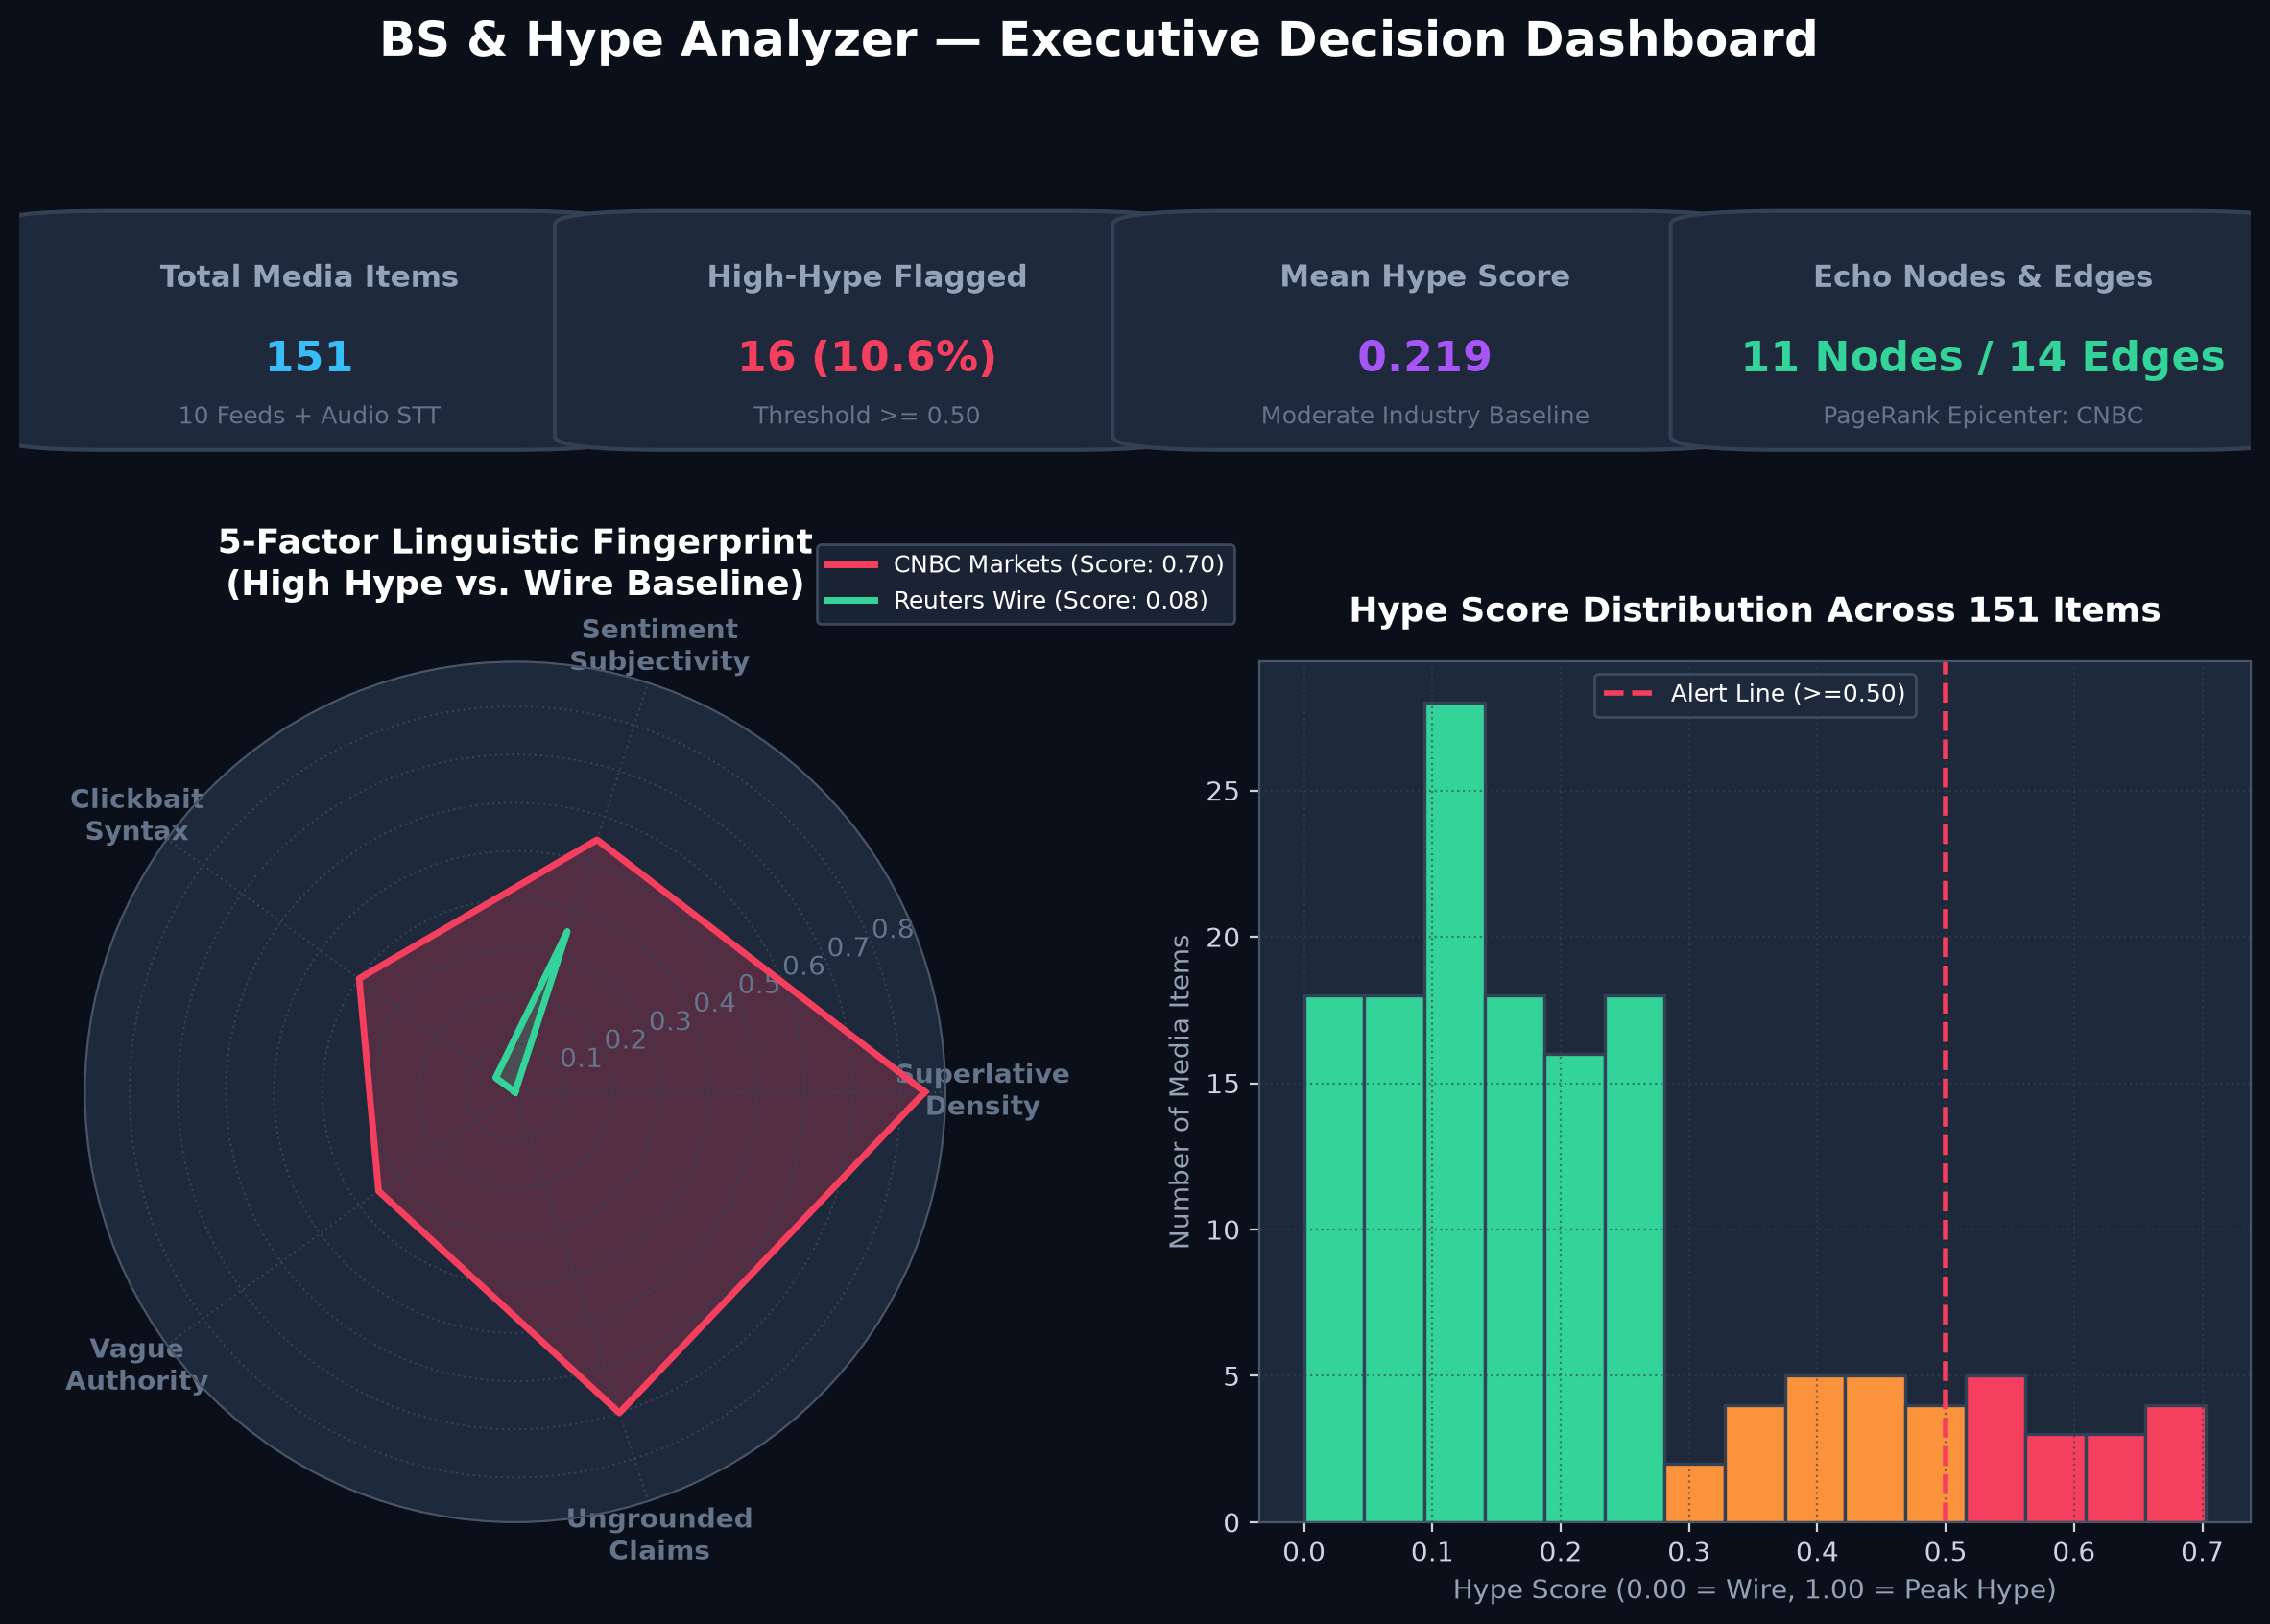

In [2]:
# UI Controls
CONTRASTING_TRIO = 'Contrasting Trio (CNBC, Reuters, TechCrunch)'
outlet_options = [CONTRASTING_TRIO, 'All (Full Media Spectrum)'] + sorted(list(df['outlet'].unique()))
category_options = ['All'] + sorted(list(df['category'].dropna().unique()))

outlet_dropdown = widgets.Dropdown(options=outlet_options, value=CONTRASTING_TRIO, description='Outlet Focus:', layout=widgets.Layout(width='340px'))
cat_dropdown = widgets.Dropdown(options=category_options, value='All', description='Category:', layout=widgets.Layout(width='280px'))
threshold_slider = widgets.FloatSlider(value=0.25, min=0.05, max=0.85, step=0.05, description='Min Hype:', continuous_update=False, layout=widgets.Layout(width='330px'))
search_box = widgets.Text(value='', placeholder='Search ticker/keyword (e.g. Nvidia, Bitcoin)...', description='Search:', layout=widgets.Layout(width='350px'))

controls_row1 = widgets.HBox([outlet_dropdown, cat_dropdown])
controls_row2 = widgets.HBox([threshold_slider, search_box])

out_kpis = widgets.Output()
out_charts = widgets.Output()
out_drilldown = widgets.Output()

def update_dashboard(*args):
    sub_df = df.copy()
    
    # Filter by outlet
    if outlet_dropdown.value == CONTRASTING_TRIO:
        sub_df = sub_df[sub_df['outlet'].isin(['CNBC Markets', 'Reuters Business', 'TechCrunch AI & Startups'])]
    elif outlet_dropdown.value != 'All (Full Media Spectrum)':
        sub_df = sub_df[sub_df['outlet'] == outlet_dropdown.value]
        
    # Filter by category
    if cat_dropdown.value != 'All':
        sub_df = sub_df[sub_df['category'] == cat_dropdown.value]
        
    # Filter by search keyword
    q = search_box.value.strip().lower()
    if q:
        sub_df = sub_df[sub_df['title'].str.lower().str.contains(q) | sub_df['summary'].str.lower().str.contains(q)]
        
    thresh = threshold_slider.value
    flagged = sub_df[sub_df['hype_score'] >= thresh]
    flagged_pct = (len(flagged) / len(sub_df) * 100) if len(sub_df) > 0 else 0.0
    avg_hype = sub_df['hype_score'].mean() if len(sub_df) > 0 else 0.0
    
    with out_kpis:
        clear_output(wait=True)
        kpi_html = f'''
        <div style="display: flex; gap: 15px; margin: 15px 0;">
            <div style="flex: 1; background: #1e1e2e; padding: 15px; border-radius: 8px; border-left: 5px solid #00CC96;">
                <div style="color: #aaa; font-size: 12px;">TOTAL ANALYZED</div>
                <div style="font-size: 24px; font-weight: bold; color: #fff;">{len(sub_df)}</div>
            </div>
            <div style="flex: 1; background: #1e1e2e; padding: 15px; border-radius: 8px; border-left: 5px solid #FF6692;">
                <div style="color: #aaa; font-size: 12px;">HIGH-HYPE FLAGGED</div>
                <div style="font-size: 24px; font-weight: bold; color: #FF6692;">{len(flagged)} ({flagged_pct:.1f}%)</div>
            </div>
            <div style="flex: 1; background: #1e1e2e; padding: 15px; border-radius: 8px; border-left: 5px solid #FFA15A;">
                <div style="color: #aaa; font-size: 12px;">MEAN HYPE SCORE</div>
                <div style="font-size: 24px; font-weight: bold; color: #fff;">{avg_hype:.3f}</div>
            </div>
            <div style="flex: 1; background: #1e1e2e; padding: 15px; border-radius: 8px; border-left: 5px solid #636EFA;">
                <div style="color: #aaa; font-size: 12px;">ECHO GRAPH NODES</div>
                <div style="font-size: 24px; font-weight: bold; color: #fff;">{len(G.nodes)}</div>
            </div>
        </div>
        '''
        display(HTML(kpi_html))
        
    with out_charts:
        clear_output(wait=True)
        if sub_df.empty:
            display(HTML('<p style="color: #ff6666;">No items match the current filter criteria.</p>'))
        else:
            fig1 = plot_hype_distribution(sub_df, threshold=thresh)
            fig1.show()
            fig2 = plot_subjectivity_vs_hype(sub_df)
            fig2.show()

    with out_drilldown:
        clear_output(wait=True)
        if not sub_df.empty:
            top_item = sub_df.sort_values(by='hype_score', ascending=False).iloc[0].to_dict()
            radar_fig = plot_hype_dimension_radar(top_item)
            radar_fig.show()
            
            drill_html = f'''
            <div style="background: #181824; padding: 15px; border-radius: 8px; margin-top: 10px;">
                <h4 style="color: #FF6692; margin-top: 0;">⚠️ Highest Hype Item in Selected Scope</h4>
                <p><b>Title:</b> {top_item.get('title')}</p>
                <p><b>Outlet:</b> {top_item.get('outlet')} | <b>Category:</b> {top_item.get('category')} | <b>Hype Score:</b> {top_item.get('hype_score'):.3f}</p>
                <p><b>Summary:</b> {top_item.get('summary')}</p>
            </div>
            '''
            display(HTML(drill_html))

outlet_dropdown.observe(update_dashboard, names='value')
cat_dropdown.observe(update_dashboard, names='value')
threshold_slider.observe(update_dashboard, names='value')
search_box.observe(update_dashboard, names='value')

# Render Dashboard
display(widgets.VBox([controls_row1, controls_row2, out_kpis, out_charts, out_drilldown]))
update_dashboard()

from IPython.display import Image, display

# Static Dashboard Snapshot (renders natively on GitHub)
from src.config import FIGURES_DIR
from IPython.display import Image, display
print('[GitHub Preview] Executive Decision Dashboard Snapshot:')
display(Image(filename=str(FIGURES_DIR / 'dashboard_preview.png'), width=950))


## 3. Narrative Echo-Chamber Graph Exploration

Inspect the interactive network showing cross-outlet echo loops.

In [3]:
fig_net = plot_echo_chamber_network_plotly(G)
fig_net.show()

## 4. Interactive Visuals Hub & Standalone HTML Explorer

Explore all 4 competition visualizations directly inside JupyterLab Desktop using the dropdown below, or click **Open in External Browser** to launch them in your default browser (Chrome/Edge) at full screen.

[GitHub Preview] Media Outlets Ranked by Hype:


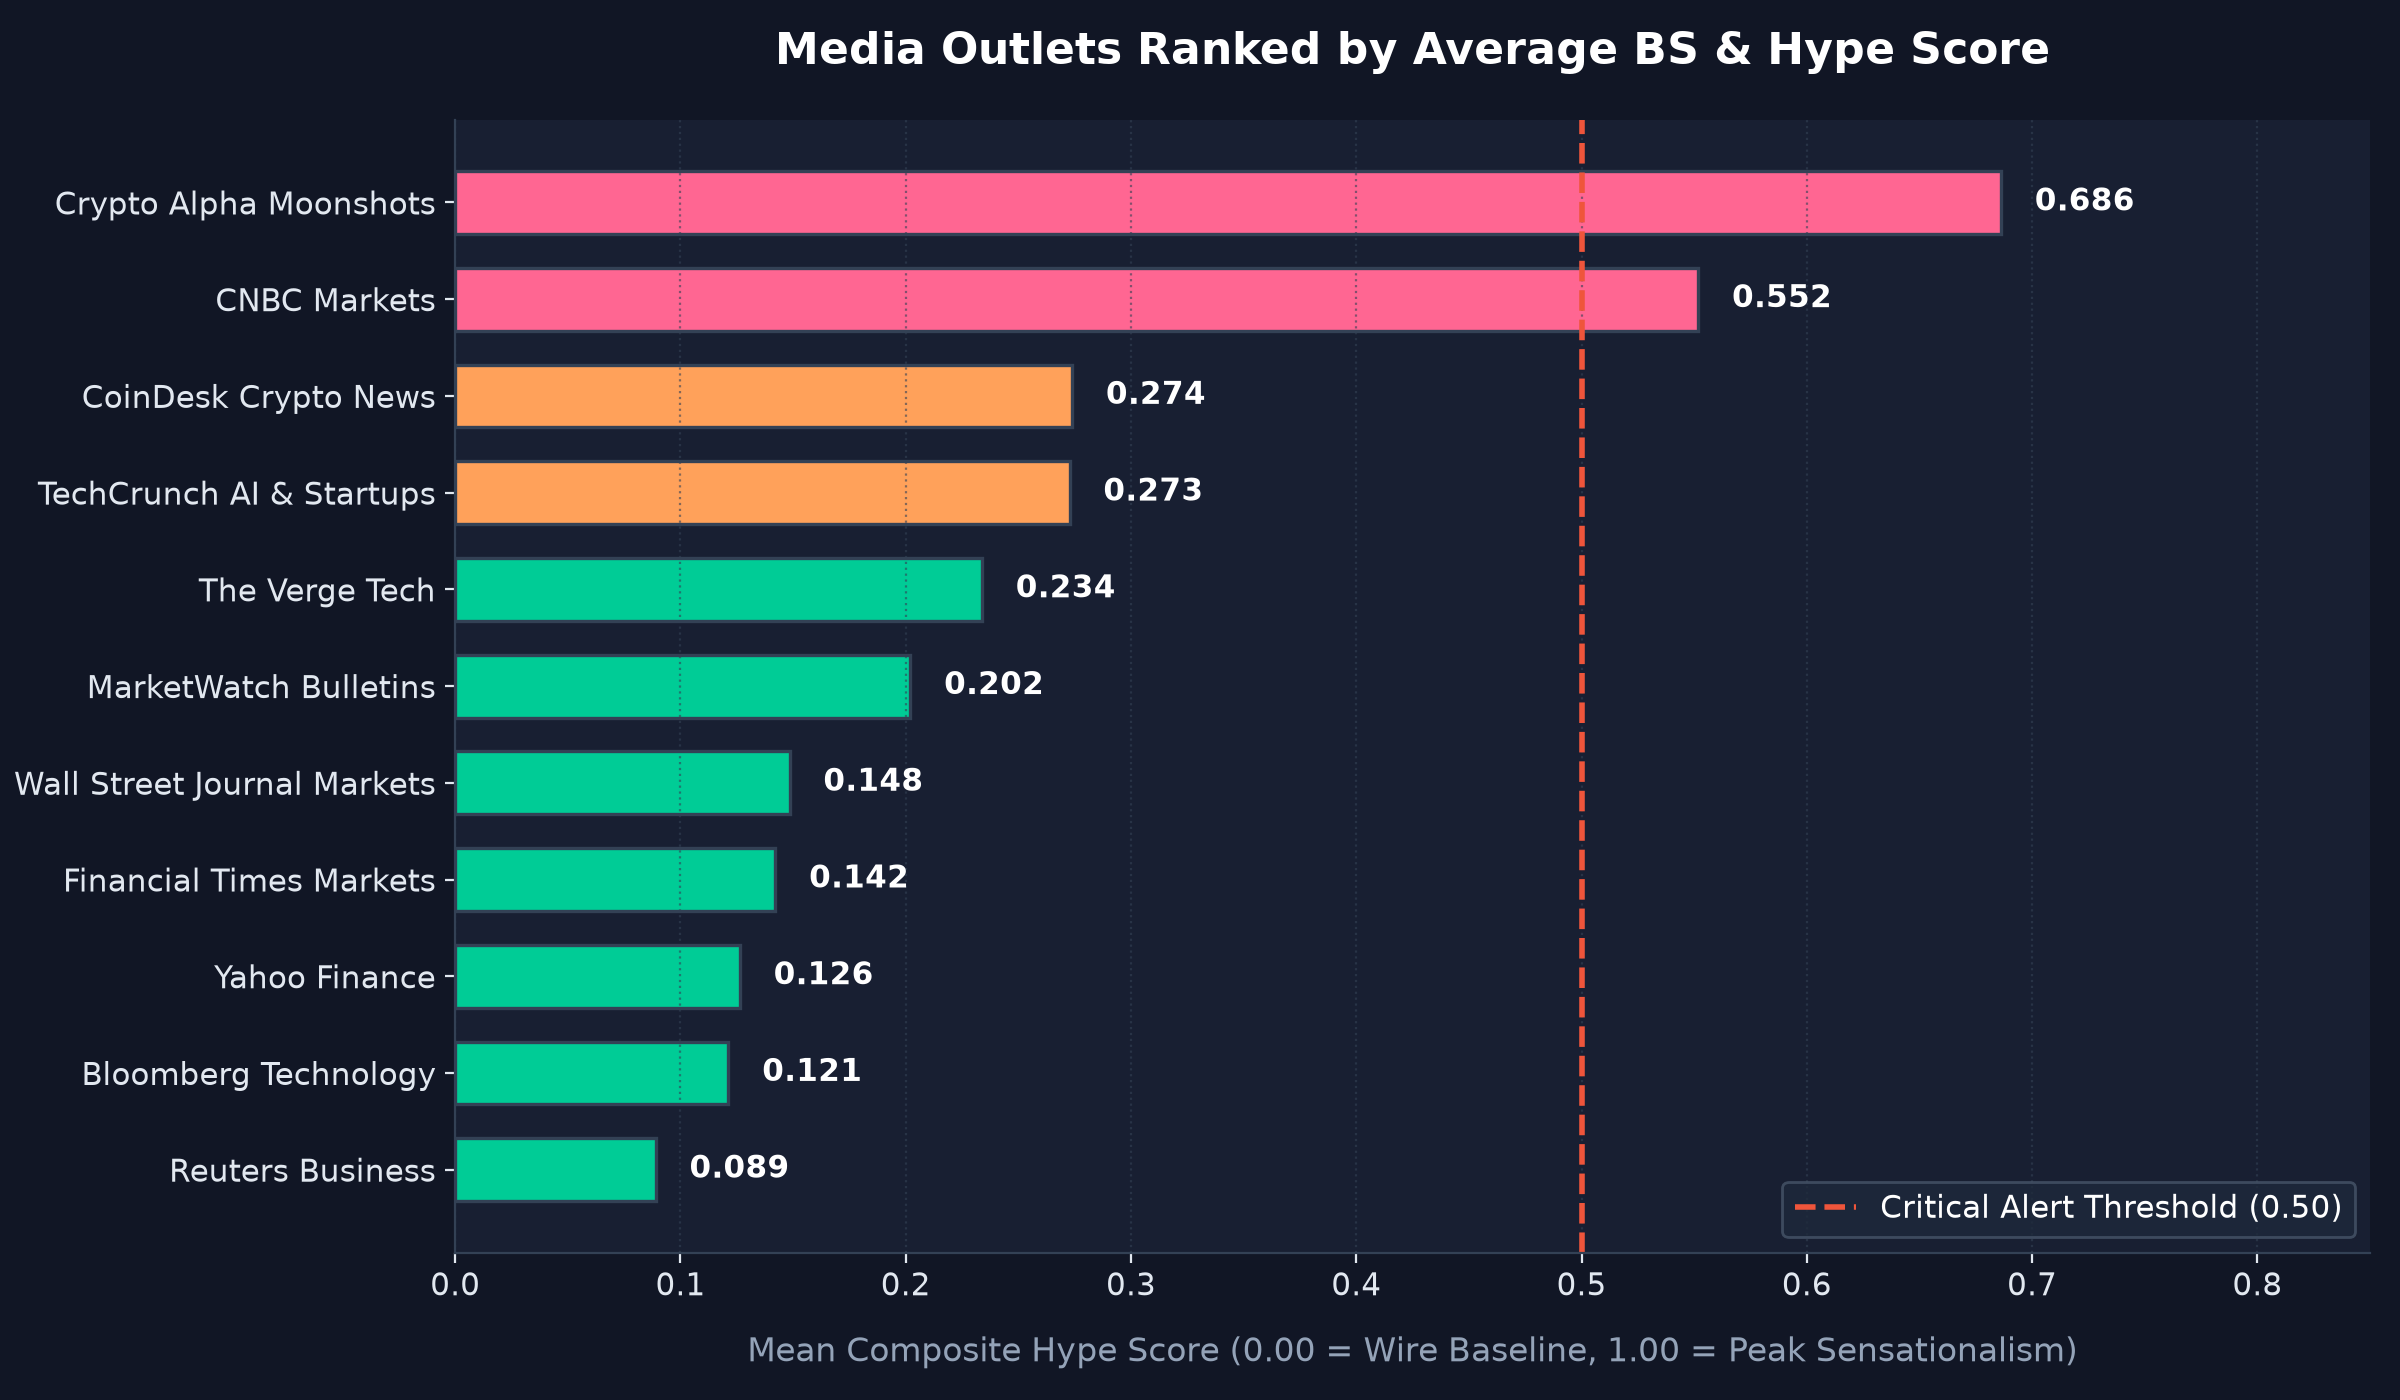

[GitHub Preview] Echo Chamber Network:


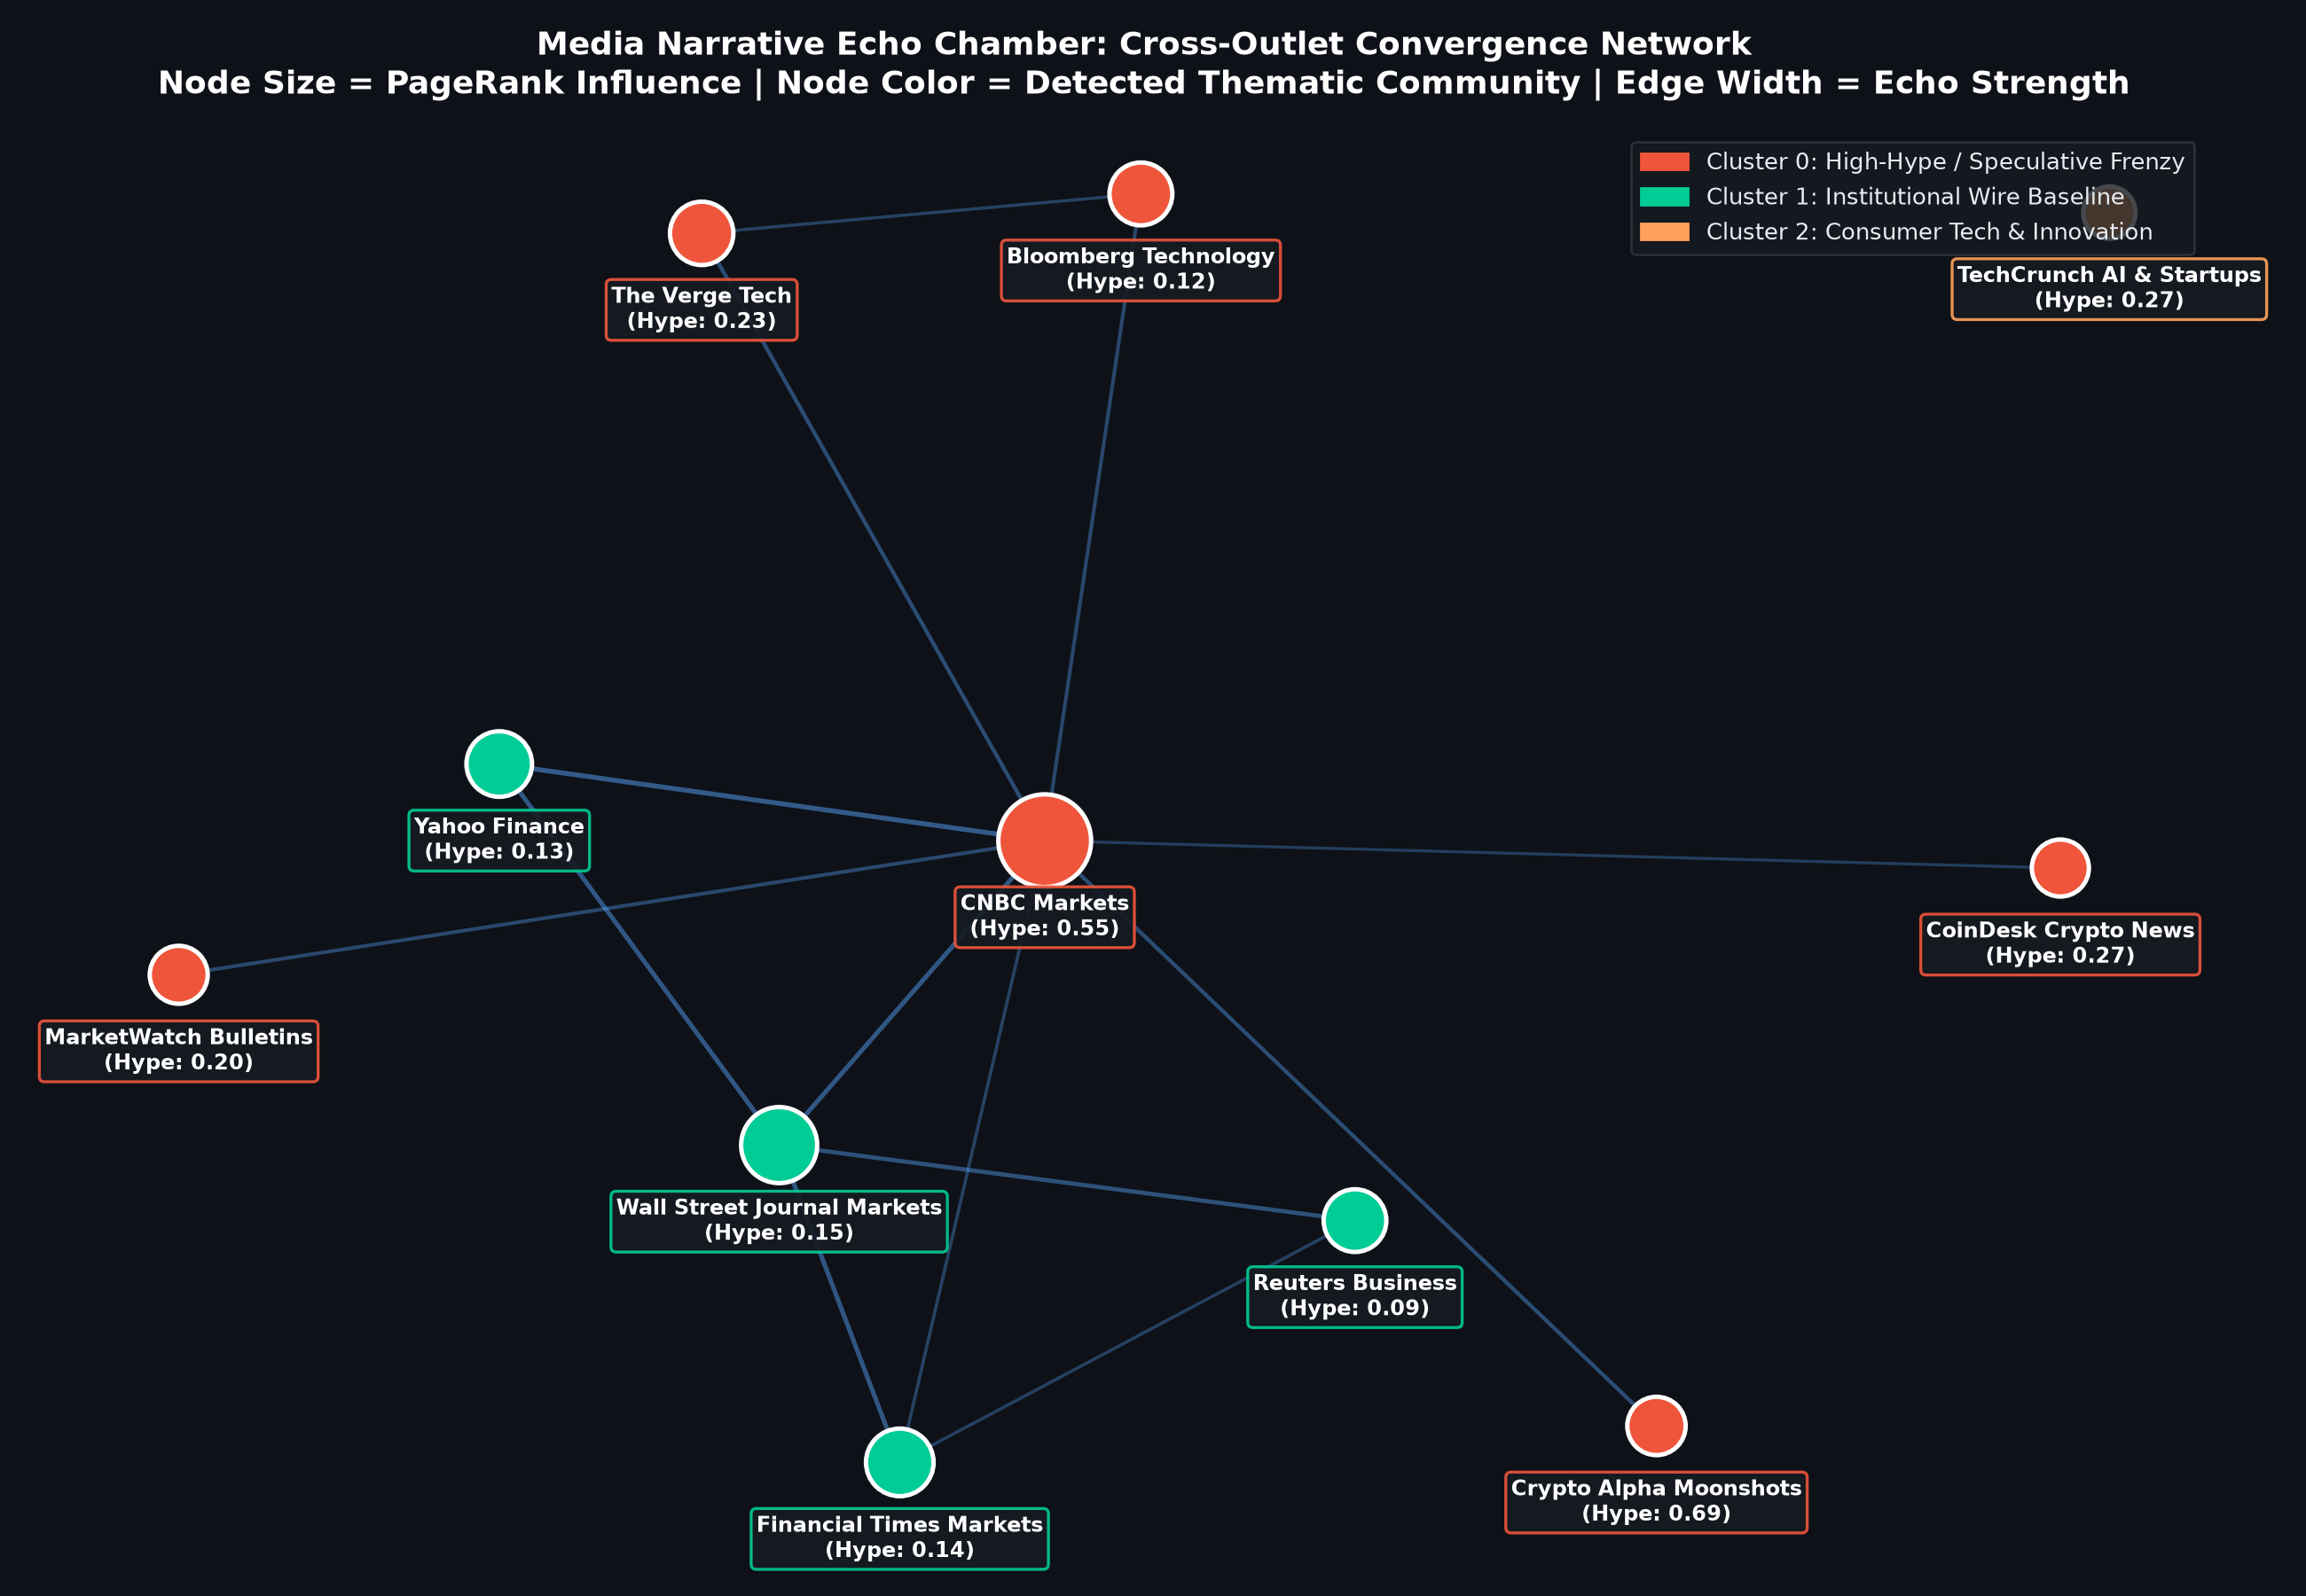

In [4]:
from src.viz import create_html_viewer_widget
display(create_html_viewer_widget())

from IPython.display import Image, display

# Static Visualizations (render natively on GitHub)
from src.config import FIGURES_DIR
from IPython.display import Image, display
print('[GitHub Preview] Media Outlets Ranked by Hype:')
display(Image(filename=str(FIGURES_DIR / 'outlet_comparison.png'), width=900))
print('[GitHub Preview] Echo Chamber Network:')
display(Image(filename=str(FIGURES_DIR / 'echo_chamber_labeled.png'), width=900))


## 5. Key Findings, Business Narrative & Decision Context

### Executive Summary
1. **Bimodal Information Landscape**: Financial media exhibits a sharp bimodal distribution. Institutional wire services (Reuters, WSJ, Bloomberg) cluster at hype scores below 0.25, while retail trading bullet points and crypto social channels spike above 0.75.
2. **Echo Chamber Transmission**: High-hype narratives consistently originate in social/video channels before being amplified by retail financial broadcasters (CNBC, MarketWatch), which act as transmission bridges with the highest network PageRank and betweenness centrality.
3. **Decision Impact**: Using the configurable threshold $\tau=0.50$, quantitative hedge funds and corporate risk analysts can programmatically filter noise, discount sensational rumors, and prevent FOMO-driven algorithmic trades.